In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Pollution Prediction**

## **Problem Definition**
### **The Objective:**

- The primary goal is to build a predictive model that accurately estimates the "Air Quality Levels" based on the provided characteristics. This model should assist governemnt and environmental organizations in evaluating the Air Quality, the causes leading to it, and steps need to be taken to improve Air Quality.

### **The Key Questions:**

- How accurately can we predict the Air Quality using the available data?
- What is the model's performance on different subset of data?
- Is there any missing data and if there is, how can it affect the accracy of the Air Quality predictions?

### **The Problem Formulation:**

- Feature Engineering: Identifying and creating the most relavant features for the data.
- Model Building: Using regression techniques (linear regression, decision trees, random forest, ridge, lasso) to build models that can predict the Air Quality.
- Model Evaluation: Evaluating the model's performance using appropriate metrics to ensure it generalizes well to unseen data.

### **Data Dictionary**
- Temperature (°C): Average temperature of the region.
- Humidity (%): Relative humidity recorded in the region.
- PM2.5 Concentration (µg/m³): Fine particulate matter levels.
- PM10 Concentration (µg/m³): Coarse particulate matter levels.
- NO2 Concentration (ppb): Nitrogen dioxide levels.
- SO2 Concentration (ppb): Sulfur dioxide levels.
- CO Concentration (ppm): Carbon monoxide levels.
- Proximity to Industrial Areas (km): Distance to the nearest industrial zone.
- Population Density (people/km²): Number of people per square kilometer in the region.
- Air Quality (**Target Variable**):
    - Good: Clean air with low pollution levels.
    - Moderate: Acceptable air quality but with some pollutants present.
    - Poor: Noticeable pollution that may cause health issues for sensitive groups.
    - Hazardous: Highly polluted air posing serious health risks to the population.

### **Loading Libraries**

In [2]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **Loading Dataset**

In [3]:
data = pd.read_csv("/content/drive/MyDrive/DataScienceProjects/pollution_dataset.csv")

### **Data Overview**

In [4]:
data.head()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


In [5]:
data. tail()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
4995,40.6,74.1,116.0,126.7,45.5,25.7,2.11,2.8,765,Hazardous
4996,28.1,96.9,6.9,25.0,25.3,10.8,1.54,5.7,709,Moderate
4997,25.9,78.2,14.2,22.1,34.8,7.8,1.63,9.6,379,Moderate
4998,25.3,44.4,21.4,29.0,23.7,5.7,0.89,11.6,241,Good
4999,24.1,77.9,81.7,94.3,23.2,10.5,1.38,8.3,461,Moderate


In [6]:
print(f"There are {data.shape[0]} rows and {data.shape[1]} columns.")

There are 5000 rows and 10 columns.


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 390.8+ KB


### **Data Cleaning**

In [8]:
# Finding missing values
data.isnull().sum()

,0
Temperature,0
Humidity,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
Proximity_to_Industrial_Areas,0
Population_Density,0
Air Quality,0


In [9]:
# Finding duplicate values
data.duplicated().sum()

np.int64(0)

### **Exploratory Data Analysis**

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

In [10]:
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Temperature,5000.0,NaN,NaN,NaN,30.02902,6.720661,13.4,25.1,29.0,34.0,58.6
Humidity,5000.0,NaN,NaN,NaN,70.05612,15.863577,36.0,58.3,69.8,80.3,128.1
PM2.5,5000.0,NaN,NaN,NaN,20.14214,24.554546,0.0,4.6,12.0,26.1,295.0
PM10,5000.0,NaN,NaN,NaN,30.21836,27.349199,-0.2,12.3,21.7,38.1,315.8
NO2,5000.0,NaN,NaN,NaN,26.4121,8.895356,7.4,20.1,25.3,31.9,64.9
SO2,5000.0,NaN,NaN,NaN,10.01482,6.750303,-6.2,5.1,8.0,13.725,44.9
CO,5000.0,NaN,NaN,NaN,1.500354,0.546027,0.65,1.03,1.41,1.84,3.72
Proximity_to_Industrial_Areas,5000.0,NaN,NaN,NaN,8.4254,3.610944,2.5,5.4,7.9,11.1,25.8
Population_Density,5000.0,NaN,NaN,NaN,497.4238,152.754084,188.0,381.0,494.0,600.0,957.0
Air Quality,5000,4,Good,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### **Observations:**
- Temperature:
    - Mean: 30.03 C with a standard deviation of 6.72 C, indicating moderate variability.
    - Range: From 13.4 C to 58.6 C, showing a wide spread in temperature.
- Humidity:
    - Mean: 70.06, with a high standard deviation of 15.86.
    - Range: 36 to 128.1 with the maximum humidity exceeding 100, which might indicate outliers or errors in the data.
- PM2.5:
    - Mean: 20.14 with large deviation of 24.55.
    - Range: From 0 to 295, showing severe air quality issue at maximum level.
- PM10:
    - Maximum value of 315.8 μg/m³ suggests high particulate matter pollution in some areas.
- Air Quality
    - The "Air Quality" variable has 4 unique categories, with "Good" being the most frequent category, appearing 2000 times out of 5000. This suggests that most samples indicate decent air quality.

In [11]:
# Making a list of all categorical variables
cat_col = list(data.select_dtypes("object").columns)

# Printing number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 50)

Air Quality
Good         2000
Moderate     1500
Poor         1000
Hazardous     500
Name: count, dtype: int64
--------------------------------------------------


### **Univariate Analysis**

In [12]:
def histogram_boxplot(data, feature, kde = False):
    plt.figure(figsize=(5,5))
    sns.boxplot(
            data = data, x = feature, showmeans = True, color = "violet"
        )  # Boxplot will be created and a star will indicate the mean value of the column

    plt.figure(figsize=(5,5))
    sns.histplot(
            data = data, x = feature, kde = True, color = "blue")
    # Adding a solid black line for the median
    plt.axvline(data[feature].median(), color='black', linestyle='-', linewidth=2, label='Median')

    # Adding a broken green line for the mean
    plt.axvline(data[feature].mean(), color='green', linestyle='--', linewidth=2, label='Mean')
    plt.show()

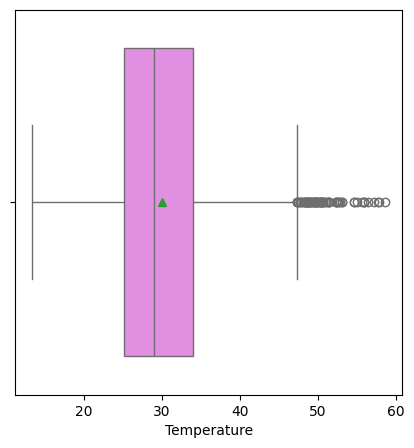

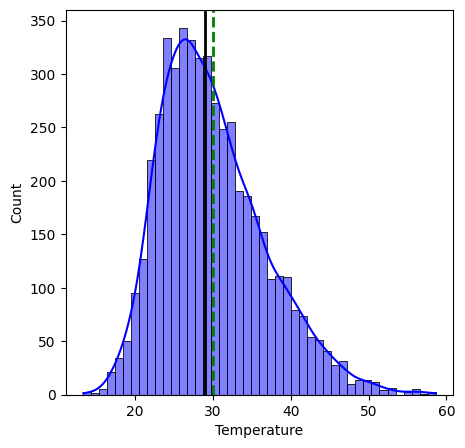

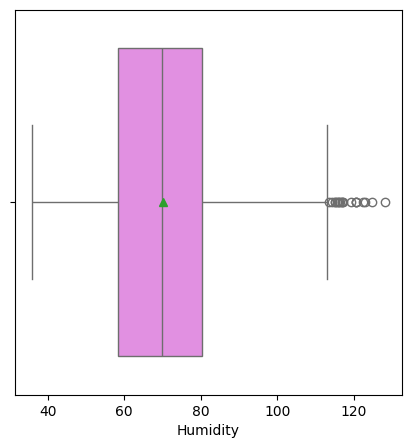

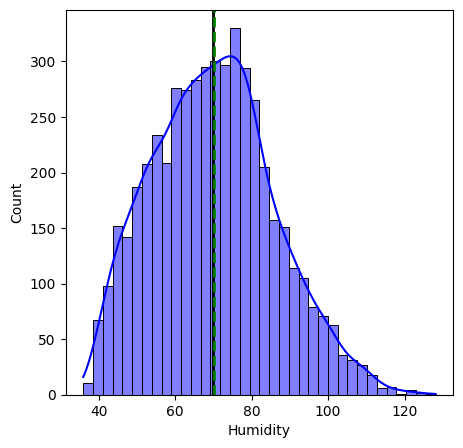

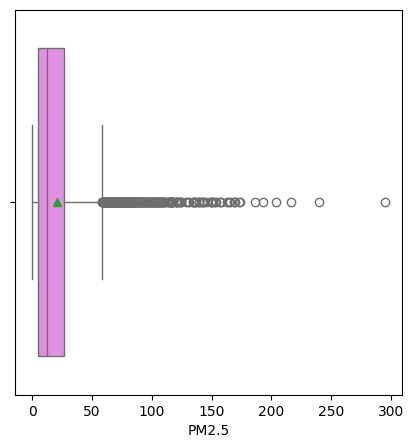

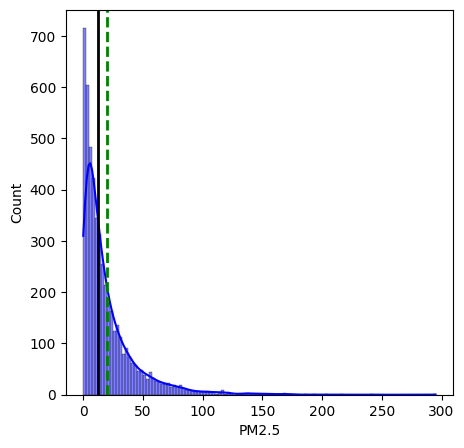

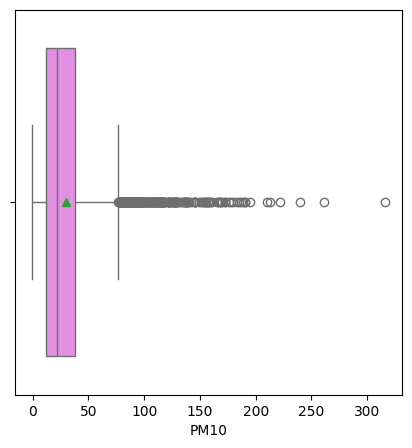

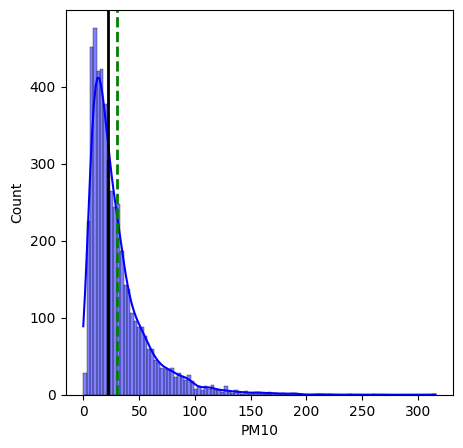

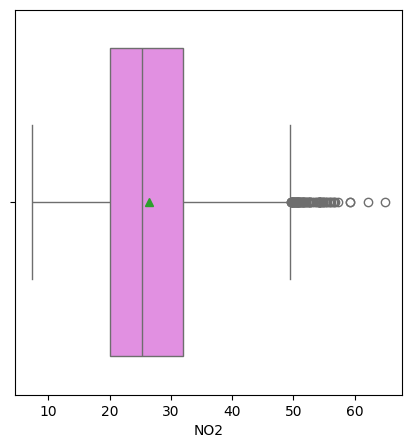

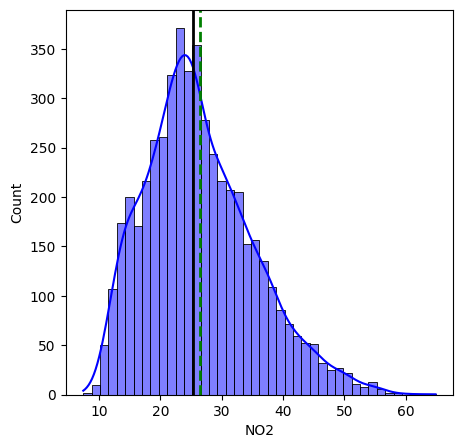

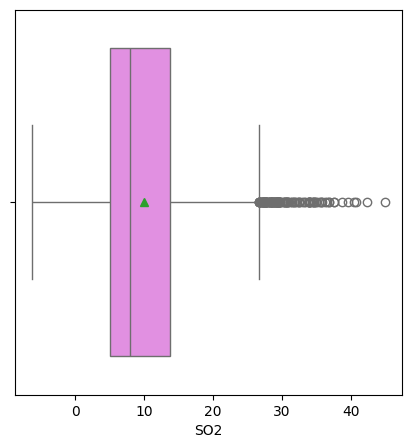

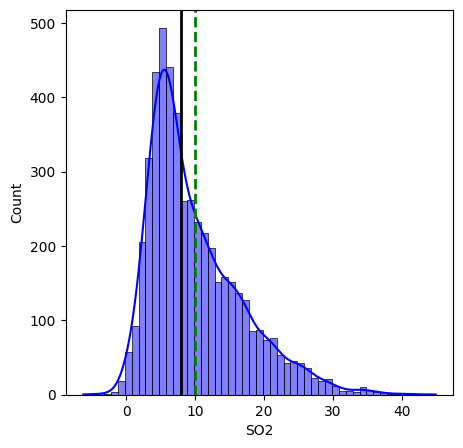

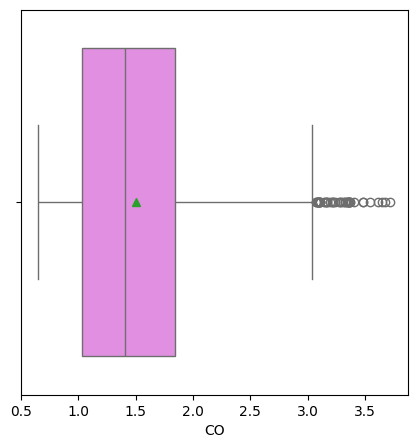

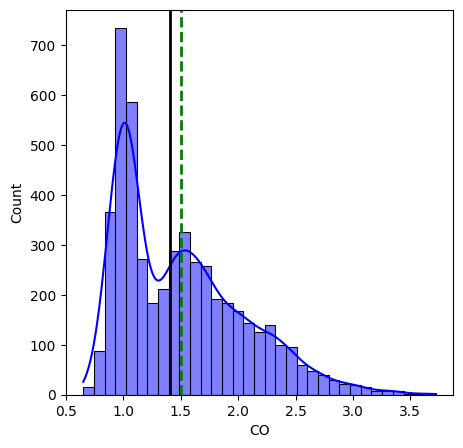

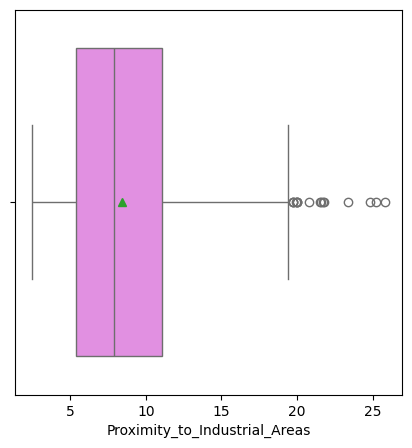

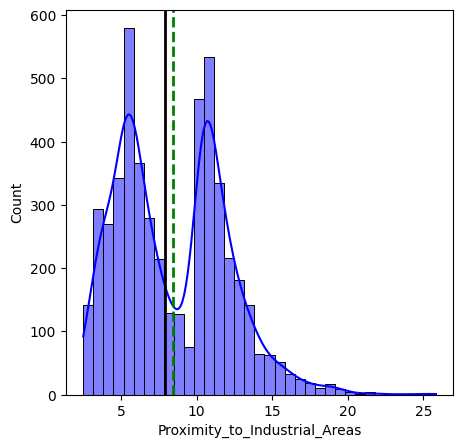

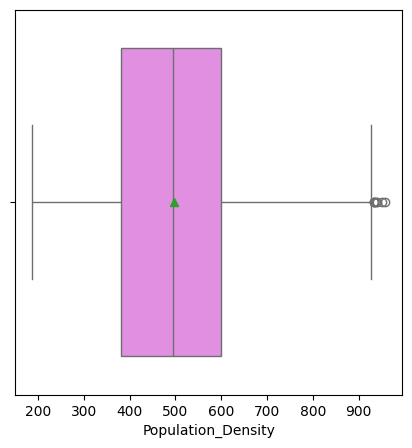

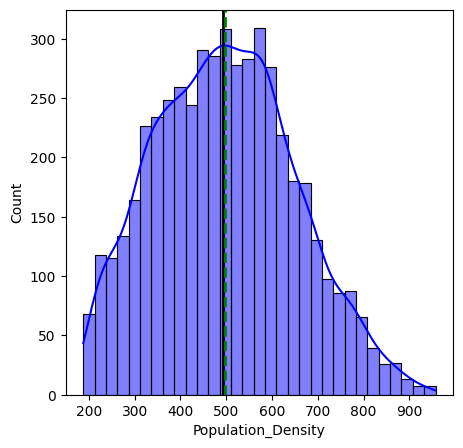

In [13]:
cols_number_list = data.select_dtypes(include = np.number).columns.tolist()

for column in cols_number_list:
    histogram_boxplot(data, column)

#### **Observations:**
- Temperature is right skewed.
- PM2.5 is right skewed.
- PM10 is right skewed.
- NO2 is slightly right skewed.
- SO2 is right skewed.
- CO is right skewed.
- Proximity_to_Industrial_Areas is right skewed.

In [14]:
def plot_categorical_count(data, column, figsize=(12,10), rotation=90):
    plt.figure(figsize=figsize)
    ax = sns.countplot(x=column, data=data, order=data[column].value_counts().index)

    # Display count values on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3, fontsize=12)

    plt.title(f"Count Plot of {column}", fontsize=14, fontweight='bold')
    plt.xlabel(column, fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.xticks(rotation=rotation, fontsize=10)
    plt.yticks(fontsize=11)
    plt.show()

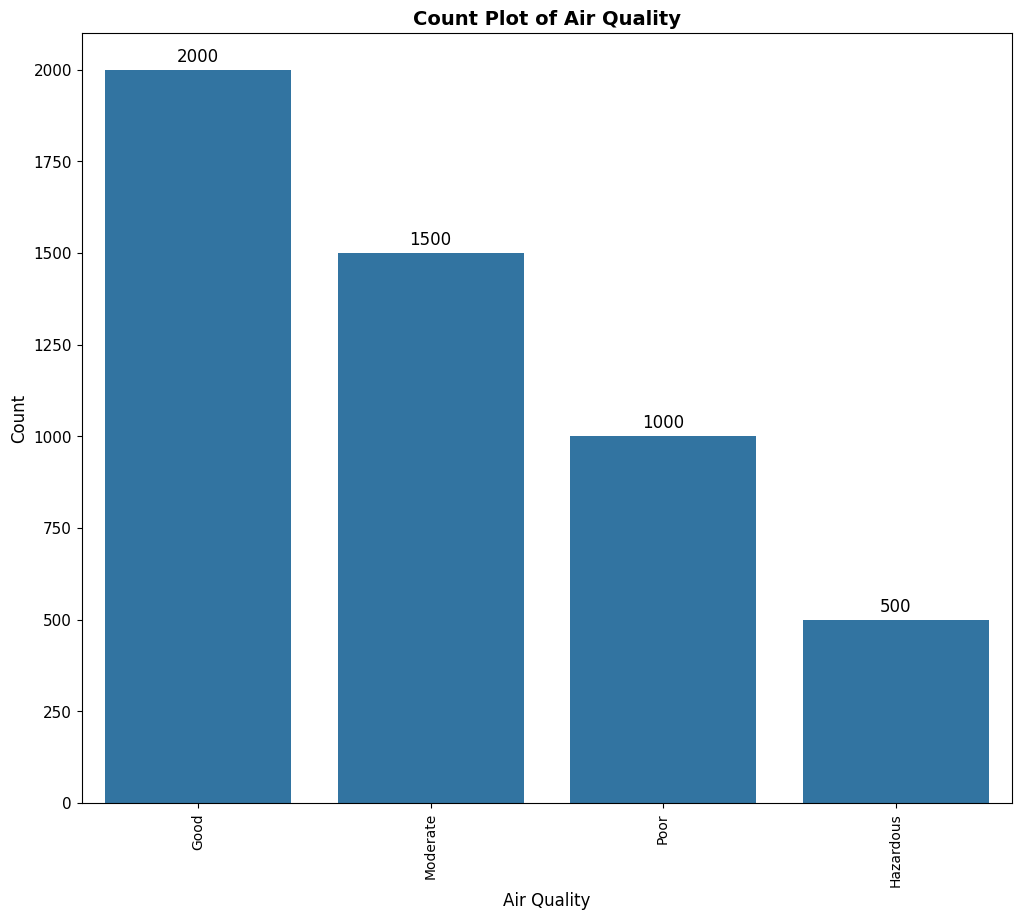

In [ ]:
cols_categorical_list = data.select_dtypes(include='object').columns.tolist()

for column in cols_categorical_list:
    plot_categorical_count(data, column)

### **Bivariate Analysis**

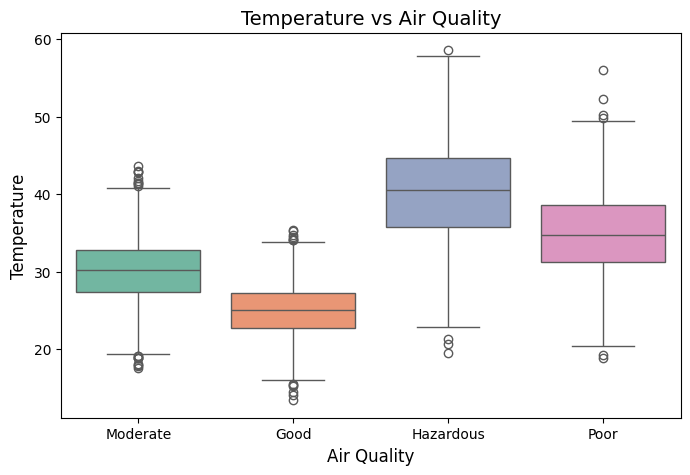

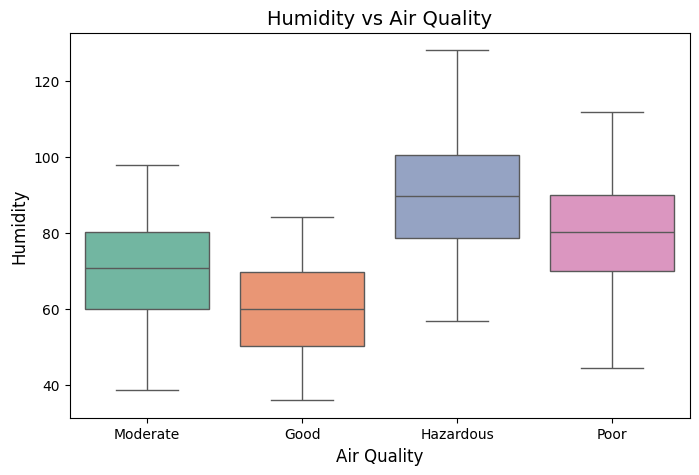

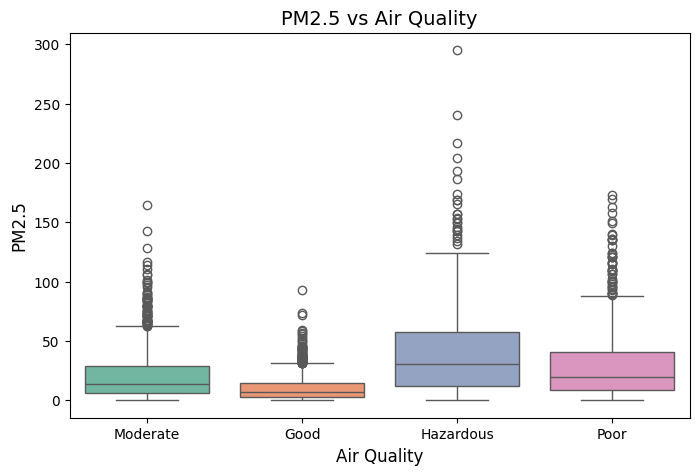

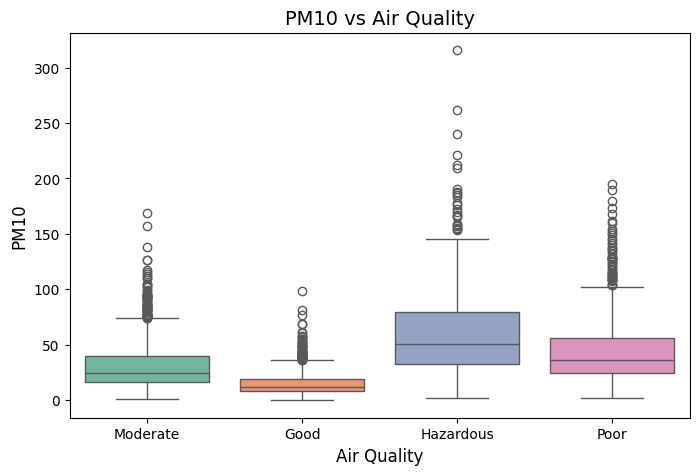

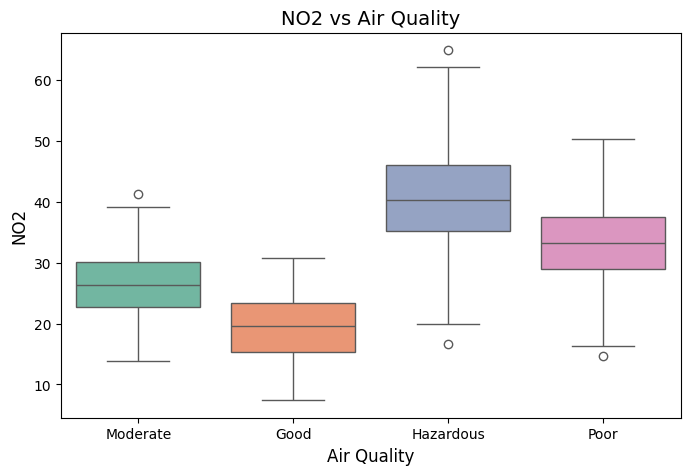

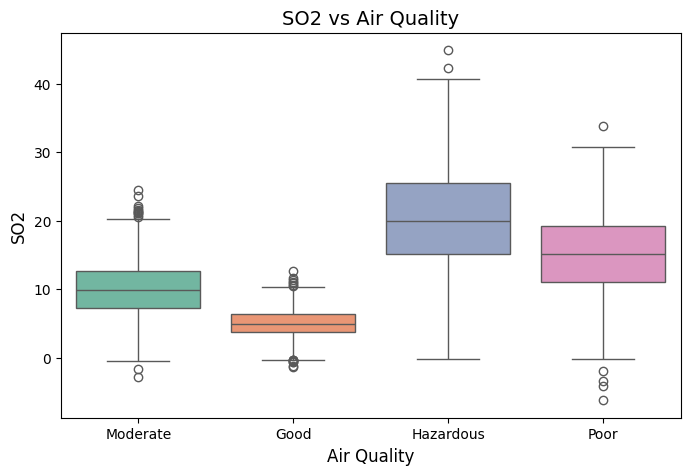

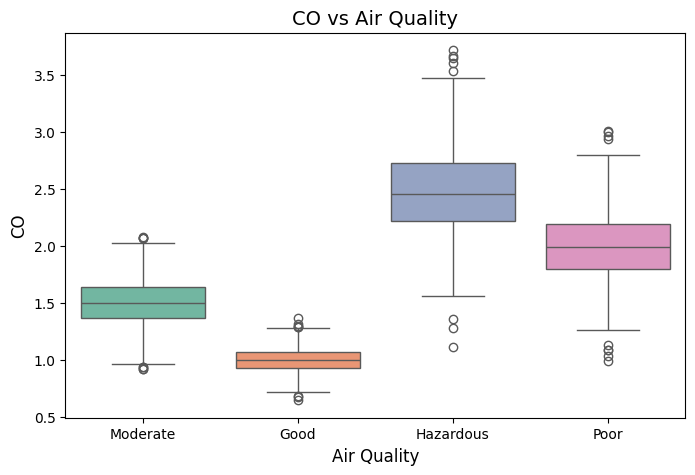

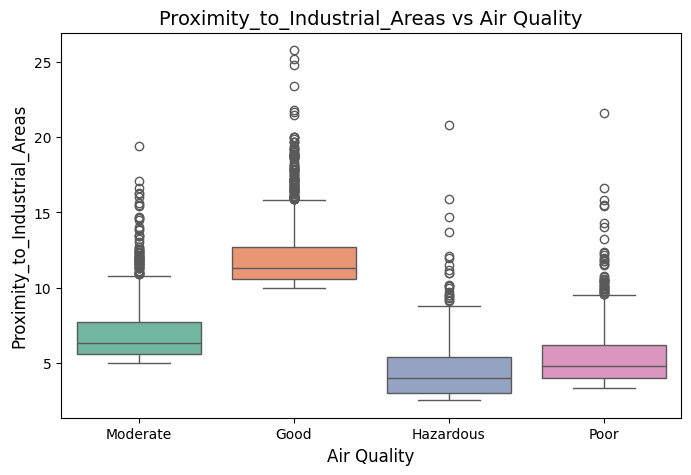

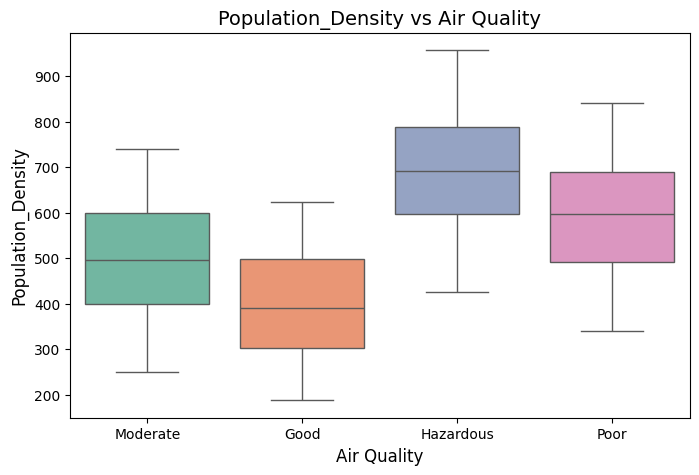

In [15]:
# Count plot to visualize the relationship of target variable "Air Quality" with other categorical features
cols_numerical_list = data.select_dtypes(include= np.number).columns.tolist()

for number in cols_numerical_list:
      plt.figure(figsize=(8, 5))
      sns.boxplot(x='Air Quality', y=number, data=data, palette='Set2', hue='Air Quality')

      # Add labels and title
      plt.xlabel("Air Quality", fontsize=12)
      plt.ylabel(number, fontsize=12)
      plt.title(f"{number} vs Air Quality", fontsize=14)

      # Show the plot
      plt.show()

### **Observations:**
- Higher temperatures and humidity levels are generally linked with poor air quality.
- Good air quality is related to low temperatures and low humidity levels.
- Extreme range of temeprature and humidy results in Hazardous air quality.
- High rage of PM2.5 and PM10 values strongly correlate to poor air quality categories.
- Good air quality is linked to minimal PM values or concentrations.
- Hazardous air quality has the highest values of PM2.5 and PM10 values which shows severe pollution conditions.
- Higher NO2 and SO2 levels are related to poor air quality.
- Good air quality has lower levels of NO2 and SO2.
- Hazardous air quality has extreme values of NO2 and SO2 showcasing severe pollution conditions.
- Higher CO levels are linked to worse air quality like 'Hazardous' and 'Poor' air qualities.
- Industrial proximity does not indicate a clear relationship with air quality as areas with high industrial proximity may have good air quality with higher median distances to industrial zones.
- High population desnity is related to lower air quality.
- Areas with hazardous and poor air quality have higher population density maybe due to urbanization and traffic.
Areas with good and moderate air quality have lower population density.

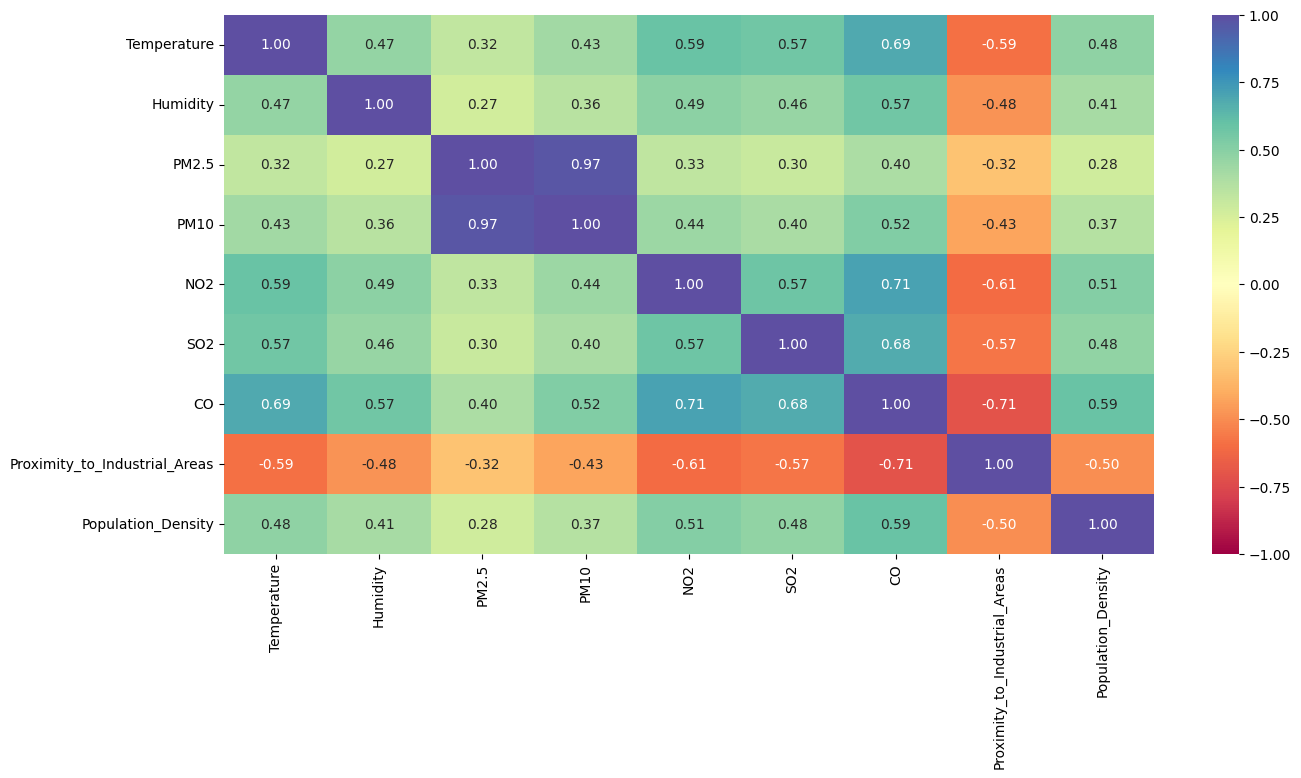

In [16]:
# Correlation check
cols_list = data.select_dtypes(include = np.number).columns.tolist()


plt.figure(figsize = (15, 7))

sns.heatmap(
    data[cols_list].corr(), annot = True, vmin = -1, vmax = 1, fmt = ".2f", cmap = "Spectral"
)

plt.show()

### **Feature Engineering**

In [17]:
df = data.copy()

In [18]:
log_columns = ['Temperature', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Proximity_to_Industrial_Areas']

for col in log_columns:
    df[f'log_{col}'] = np.log(df[col] + 1e-6)  # Adding small constant to avoid log(0)


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


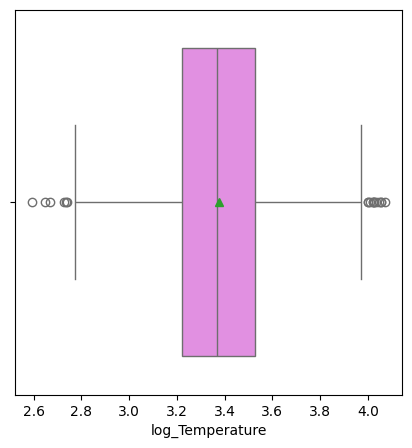

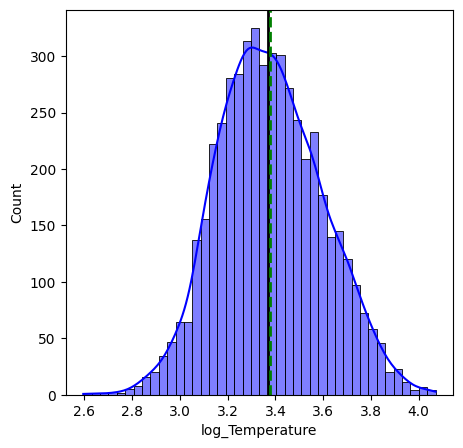

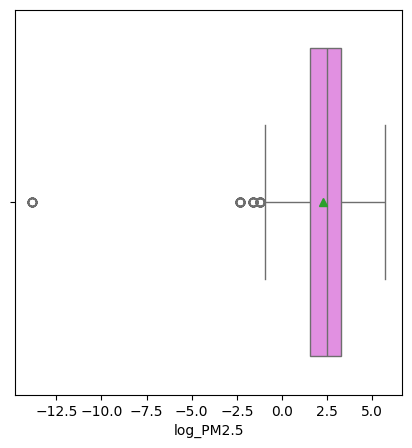

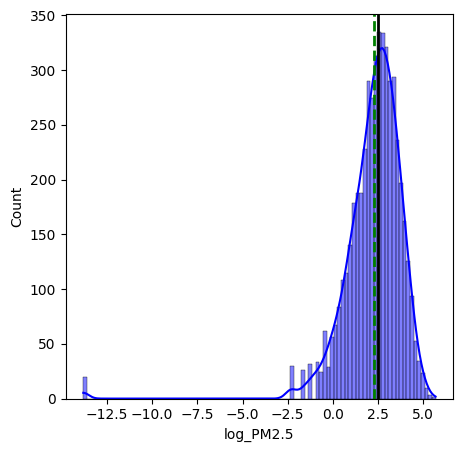

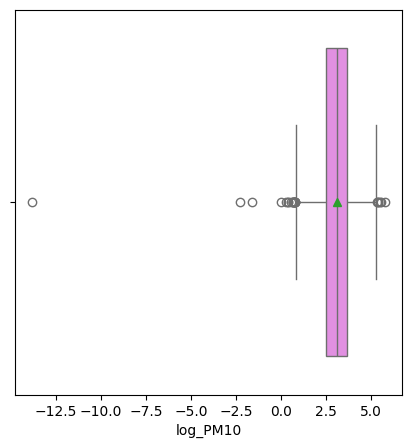

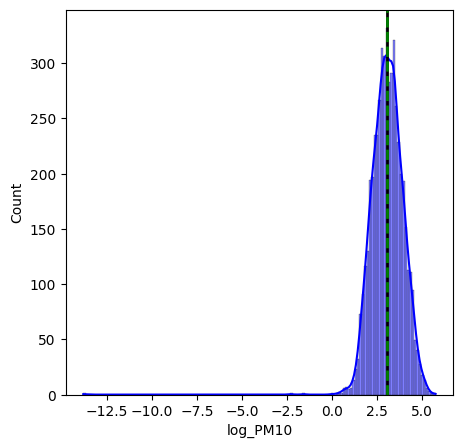

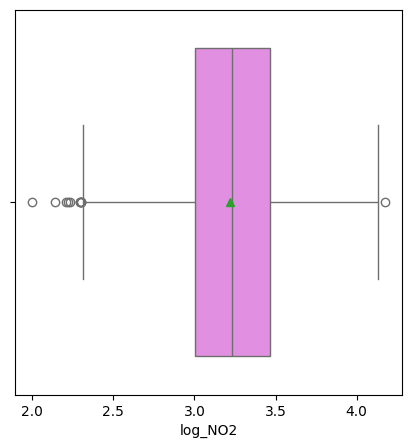

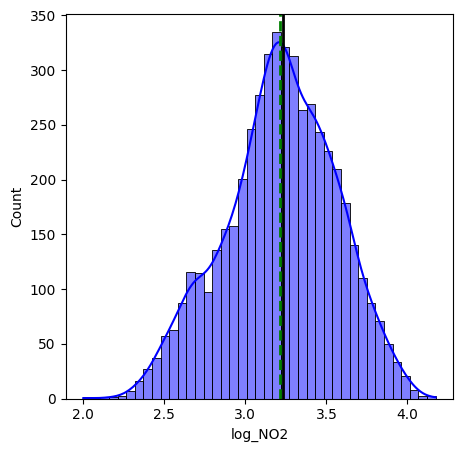

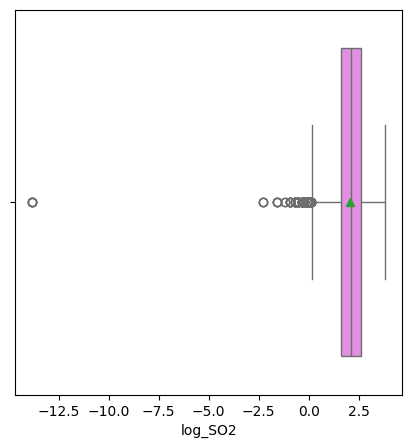

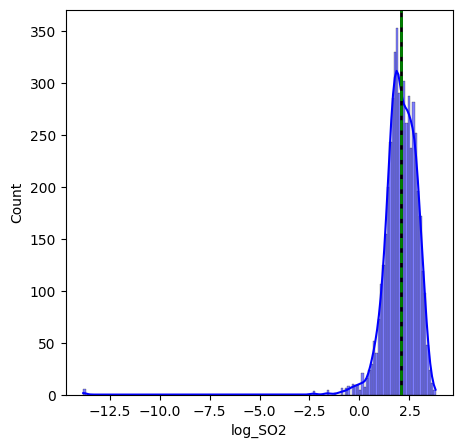

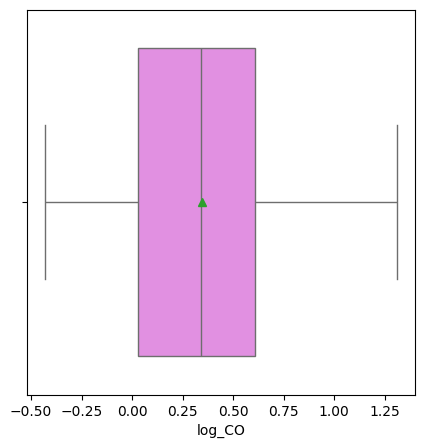

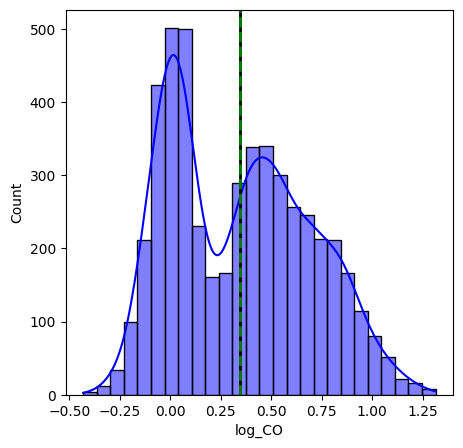

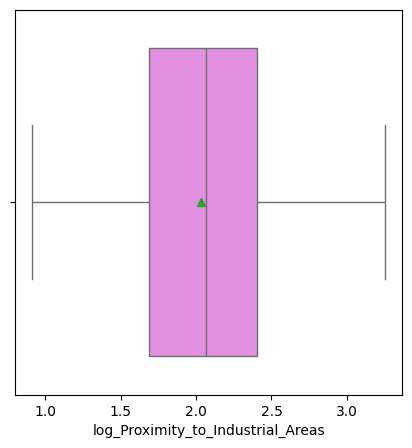

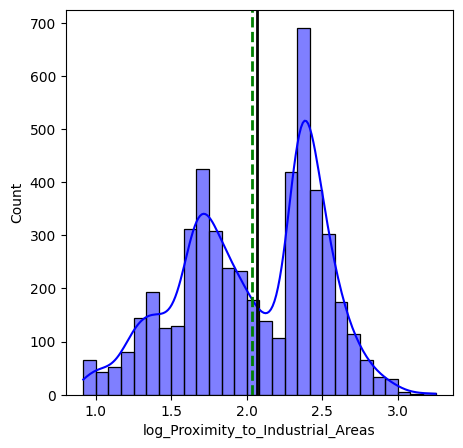

In [19]:
log_transformed_list = ['log_Temperature', 'log_PM2.5', 'log_PM10', 'log_NO2', 'log_SO2', 'log_CO', 'log_Proximity_to_Industrial_Areas']

for col in log_transformed_list:
  histogram_boxplot(df, col)


#### **Observations:**
- After log transformation to reduce skewness, PM2.5, PM10, SO2 are slightly left skewed.CO and Proximity_to_Industrial_Areas are right skewed.

In [20]:
# Winsorization (Capping)

for col in log_transformed_list:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  # Apply capping
  df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

In [21]:
df.drop(columns=['Temperature', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Proximity_to_Industrial_Areas'], inplace = True)

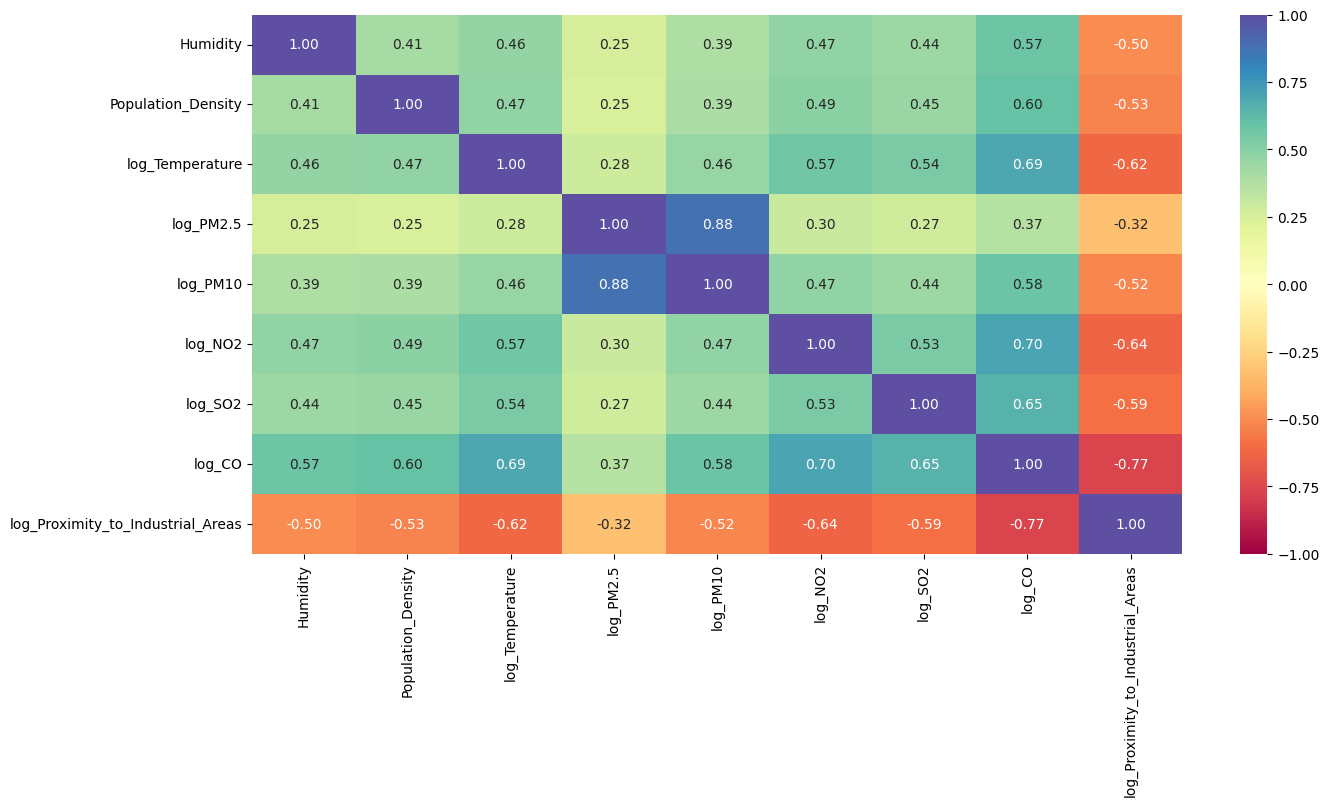

In [22]:
# Correlation check
cols_list = df.select_dtypes(include = np.number).columns.tolist()


plt.figure(figsize = (15, 7))

sns.heatmap(
    df[cols_list].corr(), annot = True, vmin = -1, vmax = 1, fmt = ".2f", cmap = "Spectral"
)

plt.show()

#### **Observations:**
- Temperature and  log_Temperature have a correlation cofficient close to 1.0 indicating perfect positive linear relationship as expected after log transformation.
- PM2.5, PM10, NO2, SO2, and CO: These pollutant variables exhibit strong positive correlations with each other (values ranging from 0.5 to 0.7), reflecting a common source or related environmental impact factors.
- Proximity_to_Industrial_Areas and log_Proximity_to_Industrial_Areas have a correlation cofficient close to 1.0 indicating perfect postive linear relationship after log transformation.
- Proximity_to_Industrial_Areas and log_Proximity_to_Industrial_Areas is negatively correlated to every feature.
- Population Density is positively correlated with pollutants like PM2.5, PM10, and NO2 (~0.5), suggesting urbanization or high human activity is a source of pollution.

In [23]:
from sklearn.preprocessing import LabelEncoder

# Label Encode target variable (if it's categorical)
if df['Air Quality'].dtype == 'object':
    le = LabelEncoder()
    df['Air Quality'] = le.fit_transform(df['Air Quality'])

# One-Hot Encoding for categorical features
df = pd.get_dummies(df, drop_first=True)

In [24]:
label_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(label_mapping)

{'Good': 0, 'Hazardous': 1, 'Moderate': 2, 'Poor': 3}


In [25]:
# Create an Air Quality Index (AQI) Feature (Weighted Sum)
data['AQI'] = (data['PM2.5'] * 0.4) + (data['PM10'] * 0.2) + (data['NO2'] * 0.2) + (data['SO2'] * 0.1) + (data['CO'] * 0.1)
df['AQI'] = (df['log_PM2.5'] * 0.4) + (df['log_PM10'] * 0.2) + (df['log_NO2'] * 0.2) + (df['log_SO2'] * 0.1) + (df['log_CO'] * 0.1)

In [27]:
# Create Interaction Features
data['Heat_Index'] = data['Temperature'] * data['Humidity']  # Interaction between Temperature & Humidity
data['Pollution_Industrial_Impact'] = data['Proximity_to_Industrial_Areas'] * (data['PM2.5'] + data['PM10'] + data['NO2'])

df['Heat_Index'] = df['log_Temperature'] * df['Humidity']  # Interaction between Temperature & Humidity
df['Pollution_Industrial_Impact'] = df['log_Proximity_to_Industrial_Areas'] * (df['log_PM2.5'] + df['log_PM10'] + df['log_NO2'])


In [28]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns
num_features = df.select_dtypes(include=['number']).columns.tolist()
num_features.remove("Air Quality")  # Exclude target variable

# Apply StandardScaler
scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])

### **Split the Data**

In [29]:
from sklearn.model_selection import train_test_split

# Define feature matrix (X) and target variable (y)
X = df.drop(columns=['Air Quality'])
y = df['Air Quality']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### **Train Logistic Regression**

In [30]:
print("NaN values in X_train:", np.isnan(X_train).sum().sum())  # Total NaNs in X_train
print("NaN values in y_train:", np.isnan(y_train).sum())  # Total NaNs in y_train

X_train.fillna(X_train.median(), inplace=True)
X_test.fillna(X_train.median(), inplace=True)

print(X_train.isna().sum())

NaN values in X_train: 46
NaN values in y_train: 0
Humidity                             0
Population_Density                   0
log_Temperature                      0
log_PM2.5                            0
log_PM10                             0
log_NO2                              0
log_SO2                              0
log_CO                               0
log_Proximity_to_Industrial_Areas    0
AQI                                  0
Heat_Index                           0
Pollution_Industrial_Impact          0
dtype: int64


In [31]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model with L2 regularization
log_reg = LogisticRegression(penalty='l2', solver='liblinear', random_state=42)

# Train the model
log_reg.fit(X_train, y_train)


LogisticRegression(random_state=42, solver='liblinear')

Logistic Regression Accuracy: 0.877

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       400
           1       0.91      0.75      0.82       100
           2       0.78      0.96      0.86       300
           3       0.82      0.58      0.68       200

    accuracy                           0.88      1000
   macro avg       0.87      0.82      0.84      1000
weighted avg       0.88      0.88      0.87      1000



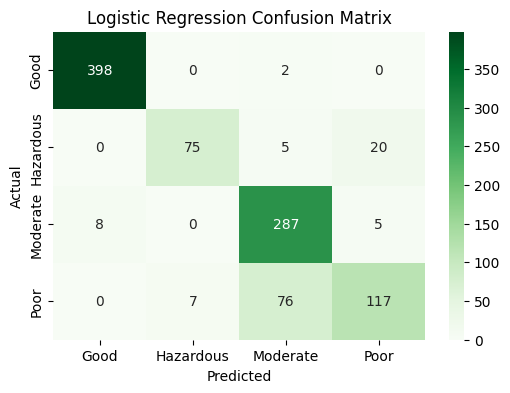

In [32]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Predict on the test set
y_pred = log_reg.predict(X_test)

# Print Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))

# Print Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Greens", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()


### **Observations:**
- The model has high accuracy of 87.7% which indicates that it performs well in general.
- Highly accurate for 'Good' air quality (Class 0).
- Decent balance for 'Moderate' (Class 2) with high recall.
- Low recall for 'Poor' (Class 3) and 'Hazardous' (Class 1).
- Overall good precision across all classes.


### **Train Random Forest Model**

In [33]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

Random Forest Accuracy: 0.952

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       0.90      0.83      0.86       100
           2       0.96      0.96      0.96       300
           3       0.87      0.90      0.88       200

    accuracy                           0.95      1000
   macro avg       0.93      0.92      0.93      1000
weighted avg       0.95      0.95      0.95      1000



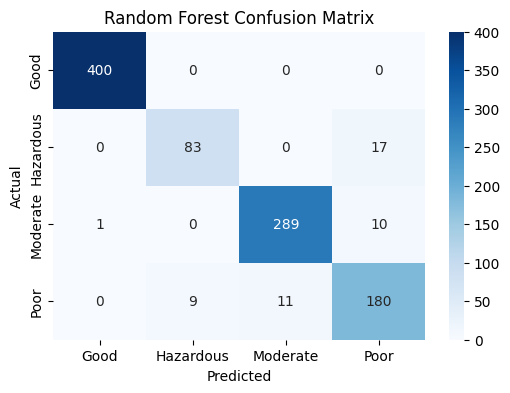

In [34]:
# Initialize and train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()


### **Observations:**
- The Random Forest model has 95.2% accuracy much better compared to Logistic Regression.
- Random Forest is capturing more complex relationships in the data.
- Class 0 (Good Air Quality):
  - Perfect classification with 100% precision, recall, and F1-score.
  - No misclassification for 'Good' air quality cases.
- Class 1 (Hazardous Air Quality):
  - The model correctly predicts 'Hazardous' air quality 90% of times.
  - 17% of actual hazardous cases are missclassified.
- Class 2 (Moderate Air Quality):
  - The model correctly predicts and recalls 'Moderate' air quality 96% of times.
  - Performance is much better than Logistic Regression.
- Class 3 (Poor Air Quality):
  - Recall is significantly better(0.98) compared to Logistic Regression (0.58).
  - Better precision (0.87), compared to Logistic Regression (0.82).
- Overall, More balanced classification across all air quality levels.
- Handles non-linearity well, which makes it more effective for real-world cases.

### **Train XGBoost Model**

In [35]:
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [36]:
# Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"Class distribution after SMOTE: {np.bincount(y_train_resampled)}")

Class distribution after SMOTE: [1600 1600 1600 1600]


XGBoost Accuracy: 0.951

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       0.88      0.86      0.87       100
           2       0.97      0.95      0.96       300
           3       0.87      0.90      0.88       200

    accuracy                           0.95      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.95      0.95      0.95      1000



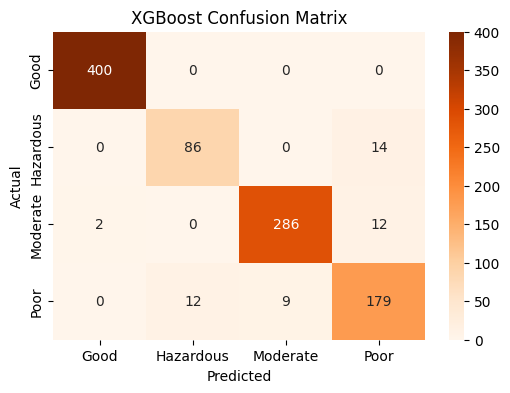

In [48]:
# Initialize and train XGBoost Classifier
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_test_proba = xgb_model.predict_proba(X_test)
test_confidence = y_test_proba.max(axis=1)

# Evaluation
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap="Oranges", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()


### **Observations:**
- The XGBoost model has 95.1% accuracy. It is similar to performance of Random Forest (95.2%).
- Both XGBoost and Random Forest effectively handle complex patterns in dataset.
- Class 0 (Good Air Quality):
  - Precision, Recall, and F1-score have perfect score of 1.0.
  - No misclassifications for 'Good' are quality cases.
- Class 1 (Hazardous Air Quality):
  - Recall (0.86) is close and better than Random Forest (0.83) and significantly better than Logistic Regression (0.75).
  - Precision (0.88) is slightly less than Random Forest (0.90) but singnificantly high.
- Class 2 (Moderate Air Quality):
  - Precision (0.97) and recall (0.95) have balanced performance which is very similar to performance of Random Forest.
- Class 3 (Poor Air Quality):
  - Recall (0.90) is same as the Random Forest and significantly better than Logistic Regression (0.58).
  - Precison (0.87) is similar to Random Forest (0.87).


### **Best Model Recommendation:**
- After thorough analysis, XGBoost is the best choice because of following reasons:
  - High accuracy (95.1%) and a balanced classification across all air quality categories.
  - XGBoost has high recall value for 'Hazardous' air quality (86%) which means fewer dangerous cases are missed as it is extremely critical in air quality monitoring.
  - It is perfect choice for long-term operations.

In [46]:
# XGBoost predictions on TRAIN
y_train_pred = xgb_model.predict(X_train)
y_train_proba = xgb_model.predict_proba(X_train)
train_confidence = y_train_proba.max(axis=1)


In [50]:
reverse_label_map = {v: k for k, v in label_mapping.items()}

# TRAIN
actual_train = y_train.map(reverse_label_map)
predicted_train = pd.Series(y_train_pred, index=y_train.index).map(reverse_label_map)

# TEST
actual_test = y_test.map(reverse_label_map)
predicted_test = pd.Series(y_pred_xgb, index=y_test.index).map(reverse_label_map)


In [51]:
train_misclassified = (actual_train.values != predicted_train.values).astype(int)
test_misclassified = (actual_test.values != predicted_test.values).astype(int)

In [52]:
##Train Table

train_table = data.loc[X_train.index].copy()

train_table['Predicted_Air_Quality'] = predicted_train.values
train_table['Prediction_Probability'] = train_confidence
train_table['Is_Misclassified'] = train_misclassified
train_table['Data_Split'] = 'Train'


In [54]:
##Test Table

test_table = data.loc[X_test.index].copy()

test_table['Predicted_Air_Quality'] = predicted_test.values
test_table['Prediction_Probability'] = test_confidence
test_table['Is_Misclassified'] = test_misclassified
test_table['Data_Split'] = 'Test'

In [56]:
## Combine Tables
final_powerbi_table = pd.concat([train_table, test_table], axis=0)


In [59]:
print(f"There are {final_powerbi_table.shape[0]} rows and {final_powerbi_table.shape[1]} columns.")

There are 5000 rows and 17 columns.


In [63]:
##Export
final_powerbi_table.to_csv('/content/drive/MyDrive/DataScienceProjects/final_powerbi_table.csv', index=False)


### **Key Insights for Government and Organizations:**
- Hazardous Air Quality cases:
  - Even with XGBoost predictive model, 14% of hazardous cases are misclassified.
  - The government of organization should increase monitoring effects and use real-time data to improve predictions.
- Moderate and Poor Air Quality cases:
  - XGBoost has high recall value for 'Poor' air quality (90%) which means it accurately predicts areas needed extra care to handle pollution.
  - The government should target areas with high 'Poor' and 'Hazardous' air quality and take important steps to improve air quality such as emission limits, strict rules and regulations for industries.
- Good Air Quality cases:
  - The model perfectly classifies 'Good' air quality which makes this model reliable.